In [1]:
import sys
import tensorflow as tf
from typing import List, Tuple, Dict, Union, Optional, Any
import tensorflow_probability as tfp
import numpy as np
tfd = tfp.distributions
tfb= tfp.bijectors

sys.path.append("..")
from MAF_spline import *
import Trainer, Bijectors

2025-05-30 15:21:45.867539: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-30 15:21:45.921866: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-30 15:21:45.922942: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-30 15:21:47.105497: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Trainer helper functions


In [2]:
def get_compiler_kwargs(lr: float,
                        ignore_nans: bool,
                        nan_threshold: float
                       ):
    #compiler_kwargs = {'optimizer': {'class_name': 'Adam', # this gives the new Adam optimizer
    compiler_kwargs = {'optimizer': {'class_name': 'Custom>Adam', # this gives the new Adam optimizer
                                     'config': {'learning_rate': lr,
                                                'beta_1': 0.9,
                                                'beta_2': 0.999,
                                                'epsilon': 1e-07,
                                                'amsgrad': True}},
                       'metrics': [{'class_name': 'MinusLogProbMetric',
                                    'config': {'ignore_nans': ignore_nans,
                                               'debug_print_mode': False}}],
                       'loss': {'class_name': 'MinusLogProbLoss',
                                'config': {'name': "MLP",
                                           'ignore_nans': ignore_nans,
                                           'nan_threshold': nan_threshold,
                                           'debug_print_mode': False}}}
    return compiler_kwargs

def get_callbacks_kwargs(#checkpoint_path: str,
                         es_min_delta: float,
                         es_patience: int,
                         lr_reduce_factor: float,
                         lr_min_delta: float,
                         lr_patience: int,
                         min_lr: float
                         ):
    callbacks_kwargs = [{'class_name': 'PrintEpochInfo',
                         'config': {}},
                        #{'class_name': 'HandleNaNCallback',
                        # 'config': {'checkpoint_path': checkpoint_path,
                        #            'lr_reduction_factor': lr_reduce_factor_on_nan,
                        #            'random_seed_var': np.random.randint(1000000)}},
                        #{'class_name': 'TerminateOnNaNFractionCallback',
                        # 'config': {'threshold': 0.1,
                        #            'validation_data': X_data_val}},
                        #{'class_name': 'ModelCheckpoint',
                        # 'config': {#'filepath': checkpoint_path,
                        #            'monitor': 'val_loss',
                        #            'save_best_only': True,
                        #            'save_weights_only': True,
                        #            'verbose': 1,
                        #            'mode': 'auto',
                        #            'save_freq': 'epoch'}},
                        {'class_name': 'EarlyStopping',
                         'config': {'monitor': 'val_loss',
                                    'min_delta': es_min_delta,
                                    'patience': es_patience,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'baseline': None,
                                    'restore_best_weights': True}},
                        {'class_name': 'ReduceLROnPlateau',
                         'config': {'monitor': 'val_loss',
                                    'factor': lr_reduce_factor,
                                    'min_delta': lr_min_delta,
                                    'patience': lr_patience,
                                    'min_lr': min_lr}},
                        {'class_name': 'TerminateOnNaN', 'config': {}}
                        ]
    return callbacks_kwargs

def get_fit_kwargs(batch_size: int,
                   epochs_input: int,
                   validation_data: Tuple[Union[np.ndarray,tf.Tensor],Union[np.ndarray,tf.Tensor]],
                   shuffle: bool,
                   verbose: int
                  ) -> Dict[str,Any]:
    fit_kwargs = {'batch_size': batch_size,
                  'epochs': epochs_input,
                  'validation_data': validation_data,
                  'shuffle': shuffle,
                  'verbose': verbose}
    return fit_kwargs

In [3]:
def gen_data2(means, stddevs, nsamples, ndims, ncomp, seed=0):

  tf.random.set_seed(seed)
  means = tf.cast(means, tf.float32)
  stddevs = tf.cast(stddevs, tf.float32)
  #questo fa che ogni riga è un sample. Per ogni sample (colonne) genera un intero da 0 a ncomp-1 per ogni dimensione
  labels = tf.random.uniform(shape=(nsamples, ndims), minval=0, maxval=ncomp, dtype=tf.int32)

  # Build gather indices: shape (nsamples, ndim, 2) where each index is [dim, label]
  dim_indices = tf.range(ndims)[tf.newaxis, :]                 # shape (1, ndim)
  dim_indices = tf.tile(dim_indices, [nsamples, 1])            # shape (nsamples, ndim)
  gather_indices = tf.stack([dim_indices, labels], axis=-1)    # shape (nsamples, ndim, 2)

  # Gather mean and std for each (sample, dimension) from (ndim, ncomp)
  chosen_means = tf.gather_nd(means, gather_indices)           # shape (nsamples, ndim)
  chosen_stds = tf.gather_nd(stddevs, gather_indices)          # shape (nsamples, ndim)

  # Sample from standard normal and scale/shift
  samples = tf.random.normal(shape=(nsamples, ndims)) * chosen_stds + chosen_means  # shape (nsamples, ndim)

  # Combine samples and labels: shape (nsamples, ndim, 2)
  data_tensor = tf.concat([samples, tf.cast(labels, samples.dtype)], axis=-1)
  label_tensor = labels

  Y_data: tf.Tensor = tf.zeros((data_tensor.shape[0], 0), dtype=data_tensor.dtype)

  return data_tensor, Y_data

### Bijector initializzation

In [4]:
event_ndims = 2
spline_knots = 8
conditional_event_shape = 2
hidden_units = [100,100]
made  = AutoregressiveNetwork(3*spline_knots-1, event_shape = event_ndims, conditional= True,
                              conditional_event_shape = conditional_event_shape, hidden_units=hidden_units,
                              activation='relu')

In [5]:
MAF_single = MaskedAutoregressiveFlow(shift_and_log_scale_fn=made,event_ndims=event_ndims,spline_knots=spline_knots,unroll_loop=True)

In [6]:
x = tf.constant([[1.0, 2.0]], dtype=tf.float32)
cond = tf.constant([[0.0, 1.0]], dtype=tf.float32)

2025-05-30 15:21:50.871074: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
out = MAF_single.forward(x, conditional_input=cond)
out2 = MAF_single.inverse(out, conditional_input=cond)
print(out.numpy())
print(out2.numpy())

[[1. 2.]]
[[1. 2.]]


In [8]:
bijector_name = 'MsplineN'
spline_knots = 8
range_min = -10
eps_regulariser = 1e-6
regulariser = 'l2'
ndims = 2
rem_dims = 1
ncond = 2
n_hidden=[100,100,100,100]
num_bijectors=4
activation='relu'
MAF = Bijectors.ChooseCondBijector(bijector_name, ndims, spline_knots, 
                            num_bijectors, range_min, n_hidden, activation, 
                            regulariser, eps_regulariser, conditional_event_shape=2, input_structure = None)

In [9]:
'''
import tensorflow as tf
import tensorflow_probability as tfp
from MAF_spline import MaskedAutoregressiveFlow, AutoregressiveNetwork # Assuming your MAF_spline.py

# Your data generation function (as provided)
def gen_data2(means, stddevs, nsamples, ndims, ncomp, seed=0):
  tf.random.set_seed(seed)
  means = tf.cast(means, tf.float32)
  stddevs = tf.cast(stddevs, tf.float32)
  labels = tf.random.uniform(shape=(nsamples, ndims), minval=0, maxval=ncomp, dtype=tf.int32)

  dim_indices = tf.range(ndims)[tf.newaxis, :]
  dim_indices = tf.tile(dim_indices, [nsamples, 1])
  gather_indices = tf.stack([dim_indices, labels], axis=-1)

  chosen_means = tf.gather_nd(means, gather_indices)
  chosen_stds = tf.gather_nd(stddevs, gather_indices)

  samples = tf.random.normal(shape=(nsamples, ndims)) * chosen_stds + chosen_means
  # data_tensor = tf.concat([samples, tf.cast(labels, samples.dtype)], axis=-1) # Original
  # For conditional MAF, we usually want samples as X and labels as condition
  # The original data_tensor concatenates them, which might not be what the MAF expects
  # Let's assume `samples` is the data `x` and `labels` is the conditional input.
  # Adjust if your MAF expects something different from data_tensor.
  # For now, I'll assume data_tensor IS the 'x' and labels are the condition.
  # If your MAF is conditional, data_tensor should be `samples`
  # and `labels` should be the `conditional_input`.

  # Let's clarify:
  # x_data will be `samples`
  # cond_data will be `tf.cast(labels, samples.dtype)`
  x_data = samples
  cond_data = tf.cast(labels, samples.dtype) # conditional input

  # Y_data is typically dummy for log_prob loss in Keras
  Y_target: tf.Tensor = tf.zeros((x_data.shape[0], 0), dtype=x_data.dtype)

  return x_data, cond_data, Y_target


def check_gradients_for_conditional_maf(
    made_network: AutoregressiveNetwork,
    maf_bijector: MaskedAutoregressiveFlow,
    base_distribution: tfp.distributions.Distribution,
    data_x_batch: tf.Tensor,
    data_cond_batch: tf.Tensor,
    is_conditional: bool = True):
    """
    Performs a manual gradient check for a conditional MaskedAutoregressiveFlow.

    Args:
        made_network: The AutoregressiveNetwork instance used by the MAF.
        maf_bijector: The MaskedAutoregressiveFlow bijector instance.
        base_distribution: The base distribution for the TransformedDistribution.
        data_x_batch: A batch of input data (features).
        data_cond_batch: A batch of conditional input data. Can be None if not conditional.
        is_conditional: Boolean indicating if the model is conditional.
    """
    if not made_network.built:
        print("Warning: MADE network is not built. Trying to build with a dummy call.")
        if is_conditional and data_cond_batch is not None:
            _ = made_network(data_x_batch, conditional_input=data_cond_batch)
        else:
            _ = made_network(data_x_batch)
        if not made_network.built:
            raise RuntimeError("Could not build the MADE network. Gradients cannot be checked.")
        print("MADE network built successfully.")


    if not maf_bijector.trainable_variables: # MAF itself doesn't have vars, but MADE does
         print("Warning: MAF bijector has no trainable variables directly. Checking MADE network's variables.")

    if not made_network.trainable_variables:
        print("ERROR: The MADE network has no trainable variables. Gradients cannot be computed.")
        return

    # Create the TransformedDistribution
    transformed_dist = tfp.distributions.TransformedDistribution(
        distribution=base_distribution,
        bijector=maf_bijector
    )

    with tf.GradientTape() as tape:
        # IMPORTANT: Watch the variables of the network that parameterizes the bijector
        tape.watch(made_network.trainable_variables)

        # --- Log Prob Calculation ---
        if is_conditional:
            if data_cond_batch is None:
                raise ValueError("data_cond_batch cannot be None if is_conditional is True.")
            # Pass conditional_input as a bijector_kwargs
            log_probs = transformed_dist.log_prob(
                data_x_batch,
                bijector_kwargs={'conditional_input': data_cond_batch}
            )
        else:
            log_probs = transformed_dist.log_prob(data_x_batch)
        # --- End Log Prob ---

        # Standard loss for density estimation
        loss = -tf.reduce_mean(log_probs)

    # Compute gradients
    gradients = tape.gradient(loss, made_network.trainable_variables)

    print(f"\n--- Gradient Check Results ---")
    print(f"Loss for batch: {loss.numpy()}")

    all_gradients_none = True
    all_gradients_zero = True
    max_grad_norm = 0.0

    if gradients is None:
        print("ERROR: `tape.gradient` returned None for all variables. Loss might not depend on watched variables.")
        return

    for i, var in enumerate(made_network.trainable_variables):
        grad = gradients[i]
        print(f"\nGradient for variable: {var.name} (Shape: {var.shape})")
        if grad is not None:
            all_gradients_none = False
            grad_norm = tf.norm(grad).numpy()
            max_abs_grad = tf.reduce_max(tf.abs(grad)).numpy()
            min_abs_grad = tf.reduce_min(tf.abs(grad)).numpy()
            num_zeros = tf.reduce_sum(tf.cast(tf.equal(grad, 0.0), tf.int32)).numpy()
            total_params = tf.size(grad).numpy()

            print(f"  Norm: {grad_norm:.4e}")
            print(f"  Max Abs: {max_abs_grad:.4e}")
            print(f"  Min Abs (non-zero if any): {min_abs_grad:.4e} (Might be 0 if many zeros)")
            print(f"  Number of zeros: {num_zeros} / {total_params} ({num_zeros/total_params*100:.2f}%)")
            # print(f"  Gradient values (sample):\n{grad.numpy().flatten()[:10]}") # Optional: print some values

            if grad_norm > 1e-12 : # A very small threshold to consider it non-zero
                all_gradients_zero = False
            if grad_norm > max_grad_norm:
                max_grad_norm = grad_norm
        else:
            print("  Gradient: None (This variable is disconnected from the loss!)")

    print("\n--- Summary ---")
    if all_gradients_none:
        print("CRITICAL: All gradients are None. The loss is completely disconnected from the MADE network's variables.")
    elif all_gradients_zero:
        print("CRITICAL: All gradients are effectively zero. The network is not learning (vanishing gradients or stuck in flat region).")
        print(f"Max gradient norm found: {max_grad_norm:.4e}")
    else:
        print(f"Gradients seem to be flowing. Max gradient norm found: {max_grad_norm:.4e}")
        print("Review individual gradient statistics above for issues like very small values or too many zeros.")

if __name__ == '__main__':
    # --- Configuration based on your previous setup ---
    ndims = 2
    nsamples_train = 1000 # Batch size for the check
    nsamples_val = 200
    ncomp = 3 # Number of mixture components per dimension

    # Example means and stddevs for gen_data2
    # Shape: (ndims, ncomp)
    means_data = tf.constant([[0., 1., 2.],       # Means for dim 0, comp 0, 1, 2
                              [-1., 0.5, 1.5]], dtype=tf.float32) # Means for dim 1, comp 0, 1, 2
    stddevs_data = tf.constant([[0.5, 0.3, 0.8],  # Stddevs for dim 0
                                [0.4, 0.6, 0.2]], dtype=tf.float32) # Stddevs for dim 1

    # Generate a batch of data
    # x_train, cond_train, _ = gen_data2(means_data, stddevs_data, nsamples_train, ndims, ncomp, seed=42)
    # For a single gradient check, use a smaller batch:
    batch_size_check = 64
    x_batch, cond_batch, _ = gen_data2(means_data, stddevs_data, batch_size_check, ndims, ncomp, seed=42)

    print(f"x_batch shape: {x_batch.shape}")
    print(f"cond_batch shape: {cond_batch.shape}")


    # --- Model Setup ---
    event_ndims_maf = 1 # MAF's event_ndims is usually 1 for vector data.
                       # Your AutoregressiveNetwork's event_shape will be [ndims]
    spline_knots = 8
    event_shape_arn = [ndims]       # AutoregressiveNetwork's event_shape is the dimensionality of x
    conditional_event_shape_arn = [ndims] # Dimensionality of the conditional input (labels in this case)
    hidden_units = [100, 100]
    range_min_rqs = -3.0 # Common range for RQS, adjust if data is scaled differently

    # 1. Create the AutoregressiveNetwork (MADE)
    # It outputs `3 * spline_knots - 1` parameters for each of the `ndims`
    made = AutoregressiveNetwork(
        params=3 * spline_knots - 1,
        event_shape=event_shape_arn,
        conditional=True,
        conditional_event_shape=conditional_event_shape_arn,
        hidden_units=hidden_units,
        activation='relu',
        name="my_made_network"
    )

    # 2. Create the MaskedAutoregressiveFlow Bijector
    # Note: If your MAF_spline.py assumes event_ndims applies to the input of MAF,
    # and your data is (batch, ndims), then event_ndims_maf should be 1.
    # The `event_size` for MAF's internal loop will be taken from the last `event_ndims_maf`
    # dimensions of the input `x` to MAF's forward/inverse.
    # If x has shape (batch, feature_dim), event_ndims_maf=1, event_size=feature_dim.
    maf_bijector = MaskedAutoregressiveFlow(
        shift_and_log_scale_fn=made, # This is actually a params_fn for RQS
        event_ndims=event_ndims_maf, # How many of the innermost dims of x are considered "event"
        spline_knots=spline_knots,
        range_min=range_min_rqs,
        name="my_maf_spline"
    )

    # 3. Create the Base Distribution
    # The base distribution should have an event_shape matching the data's event_shape
    # tfd.Sample creates a batch of independent distributions.
    # The event_shape for Sample's distribution is [], so Sample adds sample_shape as event_shape.
    base_dist = tfp.distributions.Sample(
        tfp.distributions.Normal(loc=0., scale=1.),
        sample_shape=[ndims] # This makes the event_shape of base_dist [ndims]
    )
    print(f"Base distribution event shape: {base_dist.event_shape}")
    print(f"Base distribution batch shape: {base_dist.batch_shape}")


    # --- Perform Gradient Check ---
    # Ensure MADE network is built if using Keras model `fit` is not done yet
    # A dummy call can build it.
    # _ = made(x_batch, conditional_input=cond_batch) # Call AutoregressiveNetwork directly
    # _ = maf_bijector.inverse(x_batch, conditional_input=cond_batch) # Call MAF to trigger _bijector_fn

    check_gradients_for_conditional_maf(
        made_network=made,
        maf_bijector=maf_bijector,
        base_distribution=base_dist,
        data_x_batch=x_batch,
        data_cond_batch=cond_batch,
        is_conditional=True
    )

    print("\n\n--- Gradient Check for UNCONDITIONAL case (for comparison) ---")
    # Create a new MADE without conditioning for this test
    made_unconditional = AutoregressiveNetwork(
        params=3 * spline_knots - 1,
        event_shape=event_shape_arn,
        conditional=False, # Set to False
        hidden_units=hidden_units,
        activation='relu',
        name="my_made_unconditional"
    )
    maf_unconditional = MaskedAutoregressiveFlow(
        shift_and_log_scale_fn=made_unconditional,
        event_ndims=event_ndims_maf,
        spline_knots=spline_knots,
        range_min=range_min_rqs,
        name="my_maf_unconditional"
    )
    # _ = made_unconditional(x_batch)
    # _ = maf_unconditional.inverse(x_batch)

    check_gradients_for_conditional_maf(
        made_network=made_unconditional,
        maf_bijector=maf_unconditional,
        base_distribution=base_dist,
        data_x_batch=x_batch,
        data_cond_batch=None, # No conditional input
        is_conditional=False
    )
    '''

'\nimport tensorflow as tf\nimport tensorflow_probability as tfp\nfrom MAF_spline import MaskedAutoregressiveFlow, AutoregressiveNetwork # Assuming your MAF_spline.py\n\n# Your data generation function (as provided)\ndef gen_data2(means, stddevs, nsamples, ndims, ncomp, seed=0):\n  tf.random.set_seed(seed)\n  means = tf.cast(means, tf.float32)\n  stddevs = tf.cast(stddevs, tf.float32)\n  labels = tf.random.uniform(shape=(nsamples, ndims), minval=0, maxval=ncomp, dtype=tf.int32)\n\n  dim_indices = tf.range(ndims)[tf.newaxis, :]\n  dim_indices = tf.tile(dim_indices, [nsamples, 1])\n  gather_indices = tf.stack([dim_indices, labels], axis=-1)\n\n  chosen_means = tf.gather_nd(means, gather_indices)\n  chosen_stds = tf.gather_nd(stddevs, gather_indices)\n\n  samples = tf.random.normal(shape=(nsamples, ndims)) * chosen_stds + chosen_means\n  # data_tensor = tf.concat([samples, tf.cast(labels, samples.dtype)], axis=-1) # Original\n  # For conditional MAF, we usually want samples as X and label

In [10]:
x = tf.constant([[1.0, 2.0]], dtype=tf.float32)
cond = tf.constant([[0.0, 1.0]], dtype=tf.float32)
chain_kwargs = {
  "MAF_0": {"conditional_input": cond},
  "MAF_1": {"conditional_input": cond},
  "MAF_2": {"conditional_input": cond},
  "MAF_3": {"conditional_input": cond},
}
out = MAF.forward(x, **chain_kwargs)
print(out.numpy())
out2 = MAF.forward(out, **chain_kwargs)
print(out2.numpy())


[[-1.6867044  1.0734599]]
[[-2.262814  -2.5016727]]


### Data generation

In [11]:
nsamples = 10000
nsamples_val = 1000
ncomp = 2
ndims = event_ndims
means = tf.constant([[-2.0, 2.0],     # dim 0: two component means
                     [-3.0, 3.0]])    # dim 1: two component means
stddevs = tf.constant([[0.5, 0.5],
                       [1.0, 1.0]])

x_data, y_data = gen_data2(means, stddevs, nsamples, ndims, ncomp)
x_data_val, y_data_val = gen_data2(means, stddevs, nsamples_val, ndims,ncomp)
x_data.numpy().shape

(10000, 4)

### Trainer initializzation


In [12]:
base_dist = tfd.MultivariateNormalDiag(loc=tf.zeros(ndims), scale_diag=tf.ones(ndims))
#base_dist  = tfd.JointDistributionSequential([base_x, tfd.Deterministic(cond_vector)])

In [13]:
ndims_x_actual = base_dist.event_shape[0]
print( 'min: ',tf.reduce_min(x_data[..., :ndims_x_actual]))
print( 'max: ',tf.reduce_max(x_data[..., :ndims_x_actual]))

min:  tf.Tensor(-6.37982, shape=(), dtype=float32)
max:  tf.Tensor(6.7667575, shape=(), dtype=float32)


In [14]:
### Compiler hyperparameters ###
lr: float = 0.005
ignore_nans: bool = True
nan_threshold: float = 0.01

### Initialize callbacks hyperparameters ###
es_min_delta: float = .0001
es_patience: int = 100
lr_reduce_factor: float = .5
lr_min_delta: float = .0001
lr_patience: int = 50
min_lr: float = 1e-6

### Initialzie training hyperparameters ###
batch_size: int = 128
epochs_input: int = 30
shuffle: bool = True
verbose_trainer: int = 2

### Debugging parameter
debug_print_mode: bool = False


In [15]:
NFObject: Trainer.Trainer = Trainer.Trainer(base_distribution = base_dist,
                                            flow = MAF, 
                                            x_data_train = x_data,
                                            y_data_train = y_data,
                                            compiler_kwargs = get_compiler_kwargs(lr = lr,
                                                                                  ignore_nans = True,
                                                                                  nan_threshold = nan_threshold),
                                            callbacks_kwargs = get_callbacks_kwargs(#checkpoint_path = checkpoint_path,
                                                                                    es_min_delta = es_min_delta,
                                                                                    es_patience = es_patience,
                                                                                    lr_reduce_factor = lr_reduce_factor,
                                                                                    lr_min_delta = lr_min_delta,
                                                                                    lr_patience = lr_patience,
                                                                                    min_lr = min_lr),
                                            fit_kwargs = get_fit_kwargs(batch_size = batch_size,
                                                                        epochs_input = epochs_input,
                                                                        validation_data = (x_data_val, y_data_val),
                                                                        shuffle = shuffle,
                                                                        verbose = verbose_trainer),
                                            debug_print_mode = debug_print_mode)
trainable_params: int = NFObject.trainable_params
non_trainable_params: int = NFObject.non_trainable_params

********************************************found custom MAF
data:  KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='tf.__operators__.getitem/strided_slice:0', description="created by layer 'tf.__operators__.getitem'")
cond:  KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='tf.__operators__.getitem_1/strided_slice:0', description="created by layer 'tf.__operators__.getitem_1'")
********************** using conditionals in a chain *********************
passed conditionals to:  MAF_3
passed conditionals to:  MAF_2
passed conditionals to:  MAF_1
passed conditionals to:  MAF_0


2025-05-30 15:21:52.133284: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder_1' with dtype int32 and shape [3,2]
	 [[{{node Placeholder_1}}]]
2025-05-30 15:21:52.153569: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder_1' with dtype int32 and shape [3,2]
	 [[{{node Placeholder_1}}]]
2025-05-30 15:21:52.174638: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder_1' with dtype int32 and shape [3,2]
	 [[{{nod

z:  KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='tf.where_15/SelectV2:0', description="created by layer 'tf.where_15'")
ildj:  KerasTensor(type_spec=TensorSpec(shape=(None,), dtype=tf.float32, name=None), name='tf.identity/Identity:0', description="created by layer 'tf.identity'")
Model defined.
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 2)           0           ['input_11[0][0]']               
 ingOpLambda)                                                                                     
                                                   

In [16]:
NFObject.train()

Epoch 1/30


2025-05-30 15:22:26.203 
Epoch 1/30 
	 loss: 3.0035, MinusLogProbMetric: 3.0022, val_loss: 2.2473, val_MinusLogProbMetric: 2.2461
79/79 - 29s - loss: 3.0035 - MinusLogProbMetric: 3.0022 - val_loss: 2.2473 - val_MinusLogProbMetric: 2.2461 - lr: 0.0050 - 29s/epoch - 369ms/step
Epoch 2/30
2025-05-30 15:22:27.479 
Epoch 2/30 
	 loss: 2.2464, MinusLogProbMetric: 2.2451, val_loss: 2.1888, val_MinusLogProbMetric: 2.1876
79/79 - 1s - loss: 2.2464 - MinusLogProbMetric: 2.2451 - val_loss: 2.1888 - val_MinusLogProbMetric: 2.1876 - lr: 0.0050 - 1s/epoch - 16ms/step
Epoch 3/30
2025-05-30 15:22:28.739 
Epoch 3/30 
	 loss: 2.2069, MinusLogProbMetric: 2.2057, val_loss: 2.1894, val_MinusLogProbMetric: 2.1882
79/79 - 1s - loss: 2.2069 - MinusLogProbMetric: 2.2057 - val_loss: 2.1894 - val_MinusLogProbMetric: 2.1882 - lr: 0.0050 - 1s/epoch - 16ms/step
Epoch 4/30
2025-05-30 15:22:30.001 
Epoch 4/30 
	 loss: 2.2081, MinusLogProbMetric: 2.2069, val_loss: 2.2651, val_MinusLogProbMetric: 2.2639
79/79 - 1s - lo

In [17]:
nf_dist  = NFObject.nf_dist

In [18]:
@tf.function
def sample_conditional(flow: tfb.Chain, base_dist, n, c):
    # 1) Draw all latent z in one big batch:
    z = base_dist.sample(sample_shape=n)               # shape: [n, D]
    # 2) Manually push z through each bijector in the chain
    x = z
    # Chain stores its bijectors in the order they are applied *backwards*:
    # Chain._forward does: for bij in reversed(self.bijectors): x = bij.forward(x)
    for bij in reversed(flow.bijectors):
        # If this bijector is one of your conditional MAFs, pass the condition:
        if hasattr(bij, 'custom_MAF') and bij._shift_and_log_scale_fn._conditional:
            x = bij.forward(x, conditional_input=c)
        else:
            x = bij.forward(x)
    return x

In [19]:
ns = 10000
conditionals = tf.constant([[1.0, 0.0]] * ns, dtype=tf.float32)
samples = sample_conditional(flow=nf_dist.bijector,base_dist=nf_dist.distribution,n=ns,c=conditionals)

'''
bijector_args_for_sample = create_sampling_bijector_kwargs(
    flow_bijector=nf_dist.bijector, # Pass the actual bijector from your distribution
    conditional_data=conditionals
)
samples = nf_dist.sample(ns, bijector_kwargs=bijector_args_for_sample)
'''
#samples = nf_dist.sample(ns, bijector_kwargs = {'conditional_input': conditionals})

'\nbijector_args_for_sample = create_sampling_bijector_kwargs(\n    flow_bijector=nf_dist.bijector, # Pass the actual bijector from your distribution\n    conditional_data=conditionals\n)\nsamples = nf_dist.sample(ns, bijector_kwargs=bijector_args_for_sample)\n'

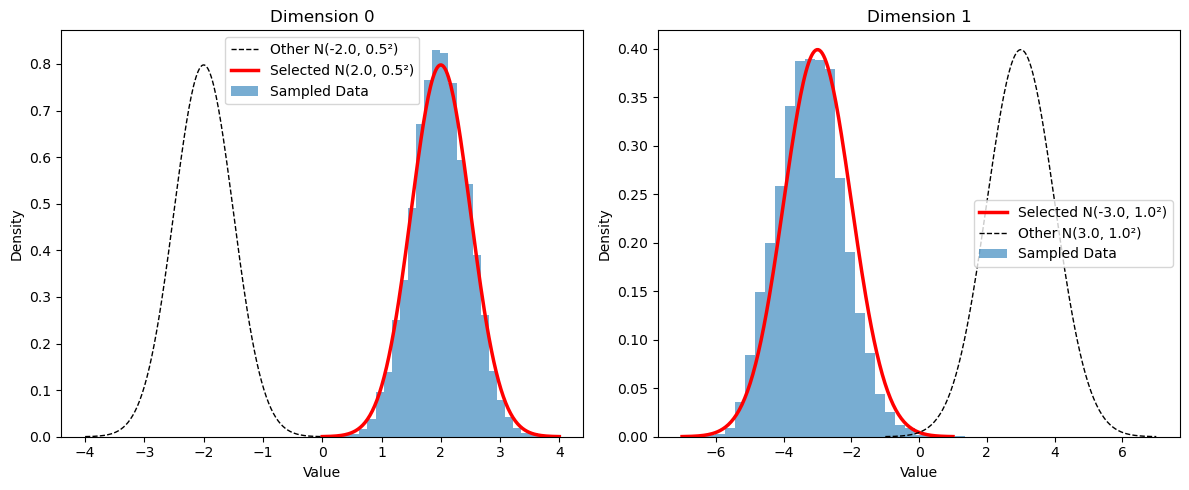

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for dim in range(2):
    selected_label = int(conditionals[0, dim].numpy())  # 0 or 1

    for comp in range(2):
        mean = means[dim, comp].numpy()
        std = stddevs[dim, comp].numpy()

        x_vals = np.linspace(mean - 4 * std, mean + 4 * std, 200)
        if comp == selected_label:
            axs[dim].plot(x_vals, norm.pdf(x_vals, mean, std), 'r-', lw=2.5, label=f'Selected N({mean}, {std}²)')
        else:
            axs[dim].plot(x_vals, norm.pdf(x_vals, mean, std), 'k--', lw=1.0, label=f'Other N({mean}, {std}²)')

    axs[dim].hist(samples[:, dim], bins=26, density=True, alpha=0.6, label='Sampled Data')
    axs[dim].set_title(f"Dimension {dim}")
    axs[dim].legend()
    axs[dim].set_xlabel("Value")
    axs[dim].set_ylabel("Density")

plt.tight_layout()
plt.show()
